# Test: Correctness Evaluation of Annotat3d Image Processing Operations

This notebook implements bitwise comparisons between ANnotat3d custum operations and well stablished open frameworks for image processing. 

In [ ]:
# Function to load and process the image
def load_image(image_path):
    # Load the image
    image = io.imread(image_path)
    
    # Convert to grayscale if it's an RGB image
    if len(image.shape) == 3:
        image = rgb2gray(image)
    
    # Normalize to 0-255 if needed for OpenCV
    if image.max() <= 1:
        image = (image * 255).astype(np.uint8)
    
    return image

# Function to apply morphology operations using scikit-image
def apply_scikit_morphology(image, operation, kernel_size=3):
    # Define the structuring element
    selem = morphology.square(kernel_size)
    
    if operation == "dilation":
        result = morphology.dilation(image, selem)
    elif operation == "erosion":
        result = morphology.erosion(image, selem)
    else:
        raise ValueError("Unsupported operation")
    
    return result

# Function to apply morphology operations using OpenCV
def apply_opencv_morphology(image, operation, kernel_size=3):
    # Define the structuring element
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    
    if operation == "dilation":
        result = cv2.dilate(image, kernel, iterations=1)
    elif operation == "erosion":
        result = cv2.erode(image, kernel, iterations=1)
    else:
        raise ValueError("Unsupported operation")
    
    return result

# Function to compare the results
def compare_results(image_path, operation, kernel_size=3):
    # Load the image
    image = load_image(image_path)
    
    # Apply scikit-image morphology
    skimage_result = apply_scikit_morphology(image, operation, kernel_size)
    
    # Apply OpenCV morphology
    opencv_result = apply_opencv_morphology(image, operation, kernel_size)
    
    # Perform bitwise comparison
    bitwise_diff = np.abs(skimage_result.astype(np.int32) - opencv_result.astype(np.int32))
    
    # Visual comparison
    plt.figure(figsize=(18, 6))
    
    # Original image
    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')
    
    # scikit-image result
    plt.subplot(1, 4, 2)
    plt.imshow(skimage_result, cmap='gray')
    plt.title(f"scikit-image {operation}")
    plt.axis('off')
    
    # OpenCV result
    plt.subplot(1, 4, 3)
    plt.imshow(opencv_result, cmap='gray')
    plt.title(f"OpenCV {operation}")
    plt.axis('off')
    
    # Bitwise difference
    plt.subplot(1, 4, 4)
    plt.imshow(bitwise_diff, cmap='hot')
    plt.title("Bitwise Difference")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Return pixel-wise statistics
    total_pixels = np.prod(image.shape)
    num_diff_pixels = np.count_nonzero(bitwise_diff)
    print(f"Total pixels: {total_pixels}")
    print(f"Different pixels: {num_diff_pixels} ({(num_diff_pixels / total_pixels) * 100:.2f}%)")
    
    return bitwise_diff

# Example usage
image_path = "path_to_your_image.jpg"  # Replace with your image path
operation = "dilation"  # Change to "erosion" for erosion
kernel_size = 5  # Adjust kernel size as needed

bitwise_diff = compare_results(image_path, operation, kernel_size)


## Import libraries

Assures that the harpia module has already been compiled with cython, before (command: python3 setup.py)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import morphology, io
from skimage.color import rgb2gray

# workaround to allow importing harpia python module
import sys
sys.path.append("../../")

import harpia.morphology.operations_binary as harpia_binary
import harpia.morphology.operations_grayscale as harpia_grayscale


In [2]:
def contiguous(array: np.ndarray) -> np.ndarray:
    if not array.flags["C_CONTIGUOUS"]:
        array = np.ascontiguousarray(array.astype(array.type()))

In [3]:
# test if all functions were imported
help(harpia)

Help on module harpia.morphology.operations_binary in harpia.morphology:

NAME
    harpia.morphology.operations_binary

FUNCTIONS
    closing_binary(hostImage, kernel, hostOutput=None, verbose=0, gpuMemory=0.9, gpu=True)
    
    dilation_binary(hostImage, kernel, hostOutput=None, verbose=0, gpuMemory=0.9, gpu=True)
    
    erosion_binary(hostImage, kernel, hostOutput=None, verbose=0, gpuMemory=0.9, gpu=True)
    
    fill_holes(hostImage, hostOutput=None, verbose=0, gpu=True)
    
    geodesic_dilation_binary(hostImage, hostMask, hostOutput=None, verbose=0, gpuMemory=0.9, gpu=True)
    
    geodesic_erosion_binary(hostImage, hostMask, hostOutput=None, verbose=0, gpuMemory=0.9, gpu=True)
    
    opening_binary(hostImage, kernel, hostOutput=None, verbose=0, gpuMemory=0.9, gpu=True)
    
    reconstruction_binary(hostImage, hostMask, operation, hostOutput=None, verbose=0, gpu=True)

DATA
    __test__ = {}

FILE
    /home/camila.araujo/Documents/harpia/harpia/morphology/operations_binar


## Framework

Useful functions to test harpia module

In [4]:
def get_vertical_line_kernel():
    kernel = np.array([[1, 0, 0], [1, 0, 0], [1, 0, 0]], dtype=np.int32)
    kernel = kernel.reshape(kernel.shape[0], kernel.shape[1], 1)
    return kernel


def get_horizontal_line_kernel():
    kernel = np.array([[1, 1, 1], [0, 0, 0], [0, 0, 0]], dtype=np.int32)
    kernel = kernel.reshape(kernel.shape[0], kernel.shape[1], 1)
    return kernel


def get_kernel():
    kernel = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]], dtype=np.int32)
    kernel = kernel.reshape(kernel.shape[0], kernel.shape[1], 1)
    return kernel

In [5]:
def read_input_uint16(filename, xsize, ysize, zsize, verbose=True):
    raw_data = np.fromfile(filename, dtype=np.uint16)
    raw_data = raw_data.astype(np.int32)

    # Check the size of the data
    if raw_data.size != xsize * ysize * zsize:
        raise ValueError(
            f"Expected {xsize * ysize * zsize} elements, but got {raw_data.size} elements."
        )
    
    # Reshape the data into the correct dimensions
    #xsize é o númeor de elementos na direção x, equivale ao númeor de 'colunas' que é a segunda dimensão para o ndarray
    image = raw_data.reshape((ysize, xsize, zsize))
    
    if(verbose):
        print("input (ysize,xsize,zsize): ", image.shape)
        
    return image


In [6]:
def show(image, output):
    # Plot the original and the processed images
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    axes[1].imshow(output, cmap="gray")
    axes[1].set_title("Processed Image")
    axes[1].axis("off")

## Read Input Image

In [7]:
image = read_input_uint16("../../example_images/binary/blobs_355x321x1_16b.raw", 355,321,1)
flag_verbose = True

input (ysize,xsize,zsize):  (321, 355, 1)


In [8]:
help(erosion_binary)

Help on fused_cython_function in module harpia.morphology.operations_binary:

erosion_binary(hostImage, kernel, hostOutput=None, verbose=0, gpuMemory=0.9, gpu=True)



## TEST: grayscale == binary?

True

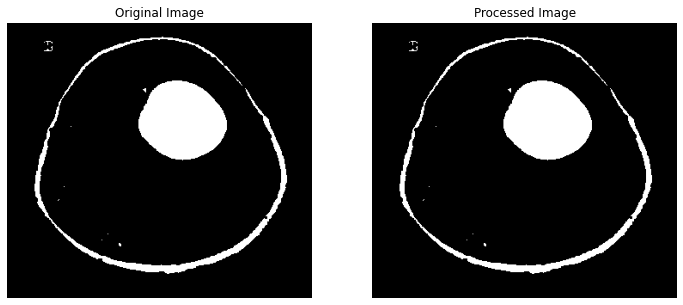

In [9]:
out_binary = erosion_binary(
    hostImage=image,
    kernel=get_kernel(),
)

out_gray = erosion_grayscale(
    hostImage=image,
    kernel=get_kernel(),
)

show(out_binary, out_gray)
(out_binary == out_gray).all()

False

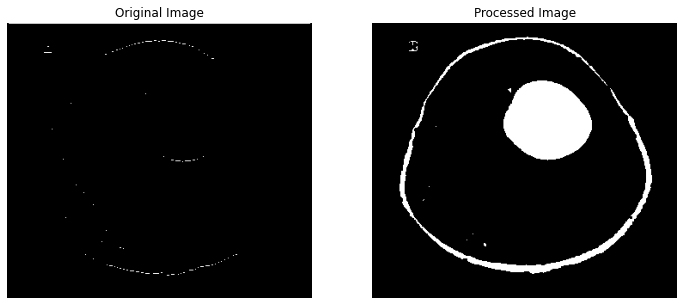

In [10]:
out_binary = erosion_binary(
    hostImage=image,
    kernel=get_horizontal_line_kernel(),
)

out_gray = erosion_grayscale(
    hostImage=image,
    kernel=get_horizontal_line_kernel(),
)

show(out_binary, out_gray)
(out_binary == out_gray).all()

## Reconstruction by Dilation

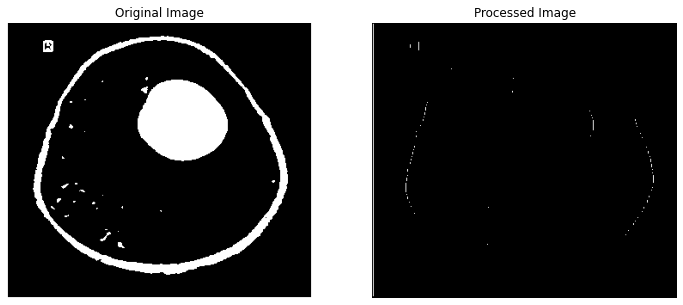

In [11]:
# Obtain the marker image
marker = erosion_binary(
    hostImage=image,
    kernel=get_vertical_line_kernel(),
)
show(image, marker)

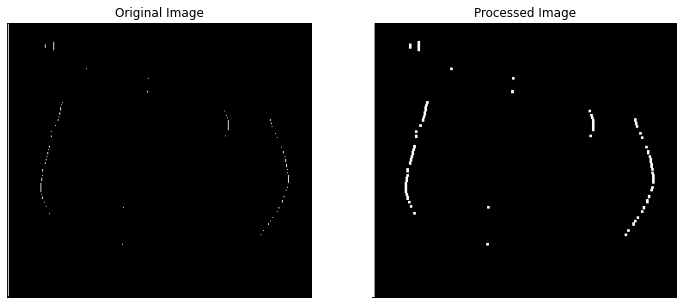

In [12]:
# Dilation
marker_dilated = dilation_binary(
    marker,
    get_kernel(),
)
show(marker, marker_dilated)

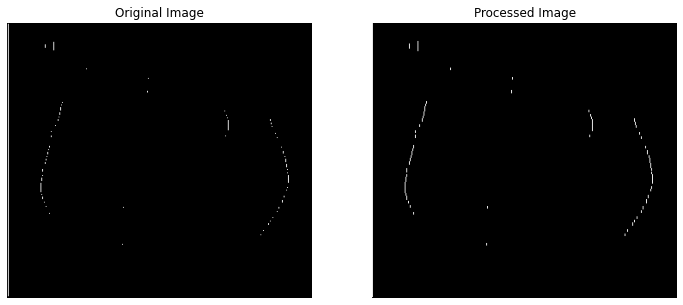

In [13]:
# Geodesic dilation (one step)
marker_geo_dilated = harpia.geodesic_dilation_binary(
    marker, image
)

show(marker, marker_geo_dilated)

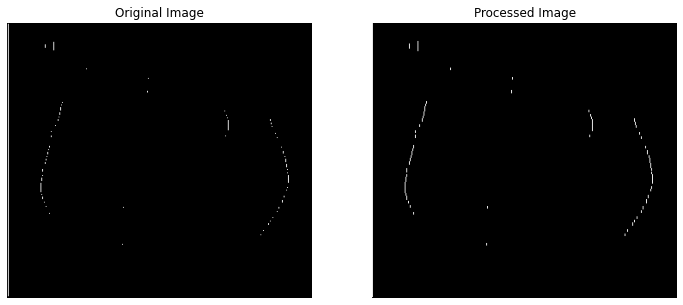

In [14]:
# Geodesic dilation (one step)
marker_geo_dilated = harpia_gray.geodesic_dilation_grayscale(
    marker, image
)
show(marker, marker_geo_dilated)

GOT IT:  515


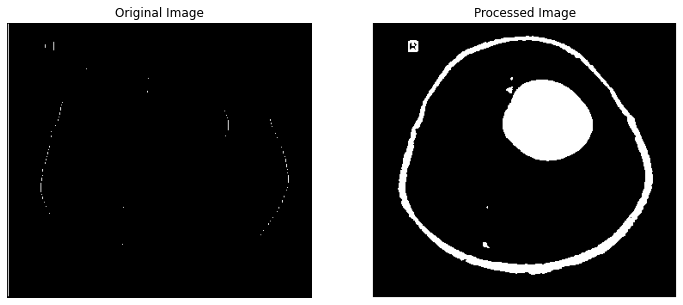

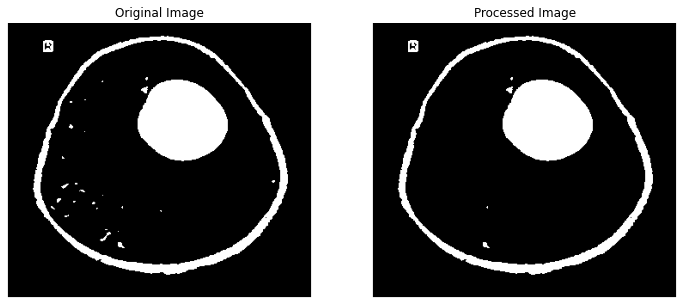

In [15]:
# Reconstruction by dilation to test geodesic dilation correctness

marker_input = marker
count = 0
for i in range(1000):
    output_aux = harpia.geodesic_dilation_binary(
        marker_input, image
    )
    count += 1
    if (marker_input == output_aux).all():
        print("GOT IT: ", count)
        break
    else:
        marker_input = output_aux
output = marker_input
show(marker, output)
show(image, output)

## Reconstruction complete

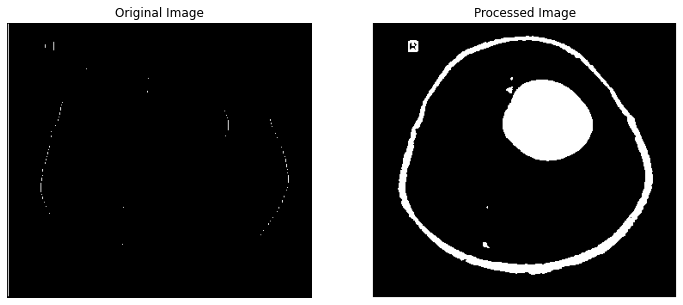

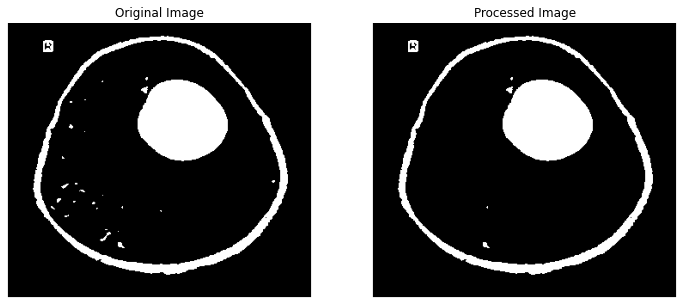

In [16]:
# Reconstruction by dilation complete
output_aux = reconstruction_binary(
    marker, image, "dilation"
)

show(marker, output_aux)
show(image, output_aux)

input (ysize,xsize,zsize):  (183, 275, 1)


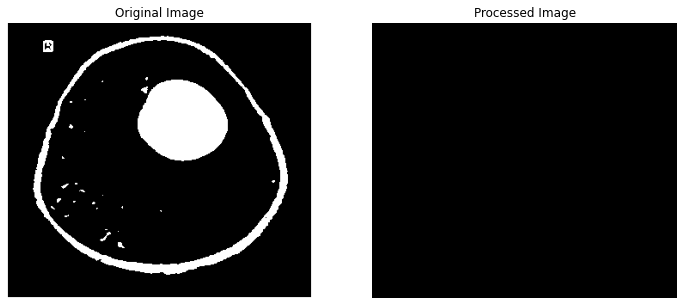

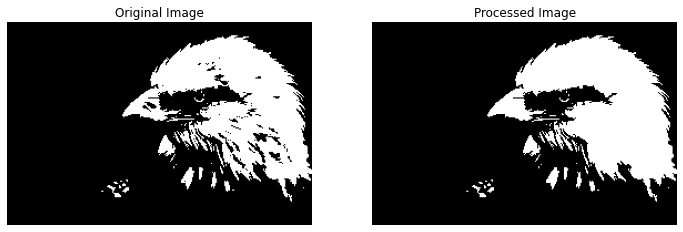

In [17]:
# Fill Holes
out = fill_holes(image)
show(image, out) #this image has a white border, so the intire image is a big 'hole'

image2 = read_input_uint16("../../example_images/binary/eagle_275x183x1_16b.raw", 275,183,1)
out2 = fill_holes(image2)
show(image2, out2) 

# TopHat e BottomHat

In [18]:
# original img
img = np.fromfile("../../example_images/grayscale/crua_A_190x207x100_16b.raw", dtype='uint16')
img = img.reshape((100, 207, 190))
img = img.astype(np.int32)

In [20]:
help( harpia_gray.top_hat)

Help on fused_cython_function in module harpia.morphology.operations_grayscale:

top_hat(hostImage, kernel, hostOutput=None, verbose=0, gpuMemory=0.9, gpu=True)



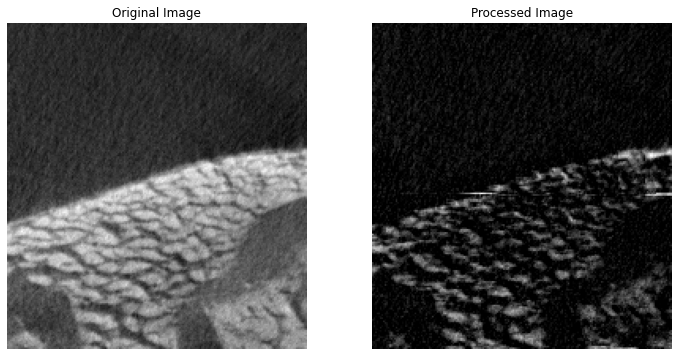

In [22]:
out = harpia_gray.top_hat(img, get_kernel())
show(img[0,:,:], out[0,:,:])

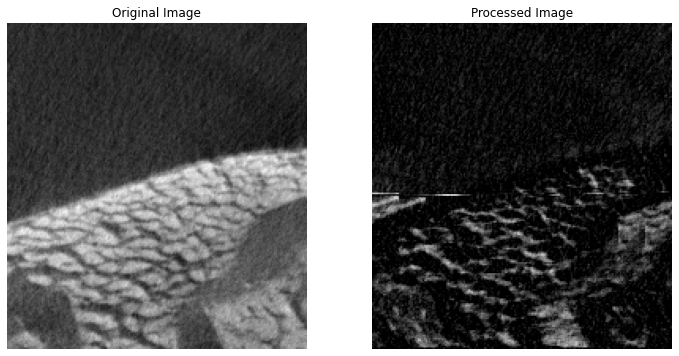

In [23]:
out = harpia_gray.bottom_hat(img, get_kernel())
show(img[0,:,:], out[0,:,:])